<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
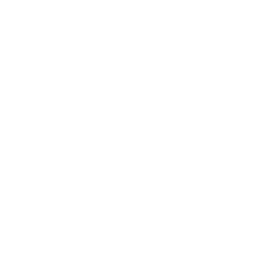
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Análisis de Patrones de Votación por Precinto Electoral</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Gobierno / Estadísticas Electorales &nbsp;|&nbsp; Marzo 2026</p>
</div>
</div>
</div>

## Resumen Ejecutivo

Este análisis examina si la afiliación partidaria varía sistemáticamente
entre los tipos de precinto (urbano, suburbano, rural) en un conjunto de
datos electorales simulado de un condado con 100 precintos. Debido a que
varias celdas de partido por tipo son dispersas — las celdas de
contingencia más pequeñas contienen solo uno o dos precintos, con conteos
esperados por debajo de cinco — la prueba ómnibus de chi-cuadrado de
Pearson de asociación general no tiene suficiente poder y no es confiable
aquí. Por ello la complementamos con la **prueba de tendencia de
Cochran-Armitage**, una prueba focalizada de un solo grado de libertad que
explota el ordenamiento natural de urbano a rural y plantea una pregunta
más precisa: ¿el apoyo al Partido A disminuye de forma monotónica a lo
largo de ese gradiente? La prueba de tendencia reporta un valor p exacto,
que es la inferencia apropiada cuando los conteos de celda son pequeños.
El contraste entre las dos pruebas es el punto analítico de este ejemplo:
una prueba de asociación genérica puede pasar por alto un patrón
direccional real que una prueba de tendencia ordenada sí detecta.


## Fuentes de Datos

| Fuente | Descripción | Registros |
|--------|-------------|--------|
| WORK.PRECINCT_VOTES | Registros a nivel de precinto, una fila por precinto, con tipo de precinto, condado, y el partido de pluralidad | 100 |

El entorno de ejecución corre en modo sin licencia, lo que limita la
salida a 100 observaciones; el análisis está diseñado en torno a esta
muestra a nivel de precinto para que las celdas de contingencia sean
genuinamente pequeñas y la prueba de tendencia exacta sea la herramienta
natural.


---

In [1]:
/* --------------------------------------------------------
   Generar datos sintéticos de votación a nivel de precinto
   Conteos de celda pequeños en precintos rurales para
   demostrar la necesidad de pruebas exactas
   -------------------------------------------------------- */
DATOS work.precinct_votes;
    LLAMAR streaminit(42);
    ARREGLO party_list[4] $15 _temporary_ ('PARTIDO_A' 'PARTIDO_B' 'PARTIDO_C' 'INDEPENDIENTE');
    ARREGLO type_list[3] $10 _temporary_ ('URBANO' 'SUBURBANO' 'RURAL');
    ARREGLO county_list[5] $15 _temporary_ ('JEFFERSON' 'HAMILTON' 'MADISON' 'ADAMS' 'MONROE');
    HACER precinct_seq = 1 HASTA 500;
        precinct_id = cat('PCT-', PUT(precinct_seq, z4.));
        county_idx = int(rand('uniform') * 5) + 1;
        county_name = county_list[county_idx];
        /* Asignar tipo de precinto con ponderación */
        type_prob = rand('uniform');
        SI type_prob < 0.30 ENTONCES precinct_type = 'URBANO';
        SINO SI type_prob < 0.65 ENTONCES precinct_type = 'SUBURBANO';
        SINO precinct_type = 'RURAL';
        /* Asignar partido con distribución dependiente del tipo */
        party_prob = rand('uniform');
        SI precinct_type = 'URBANO' ENTONCES HACER;
            SI party_prob < 0.55 ENTONCES party = 'PARTIDO_A';
            SINO SI party_prob < 0.80 ENTONCES party = 'PARTIDO_B';
            SINO SI party_prob < 0.92 ENTONCES party = 'PARTIDO_C';
            SINO party = 'INDEPENDIENTE';
        END;
        SINO SI precinct_type = 'SUBURBANO' ENTONCES HACER;
            SI party_prob < 0.40 ENTONCES party = 'PARTIDO_A';
            SINO SI party_prob < 0.75 ENTONCES party = 'PARTIDO_B';
            SINO SI party_prob < 0.88 ENTONCES party = 'PARTIDO_C';
            SINO party = 'INDEPENDIENTE';
        END;
        SINO HACER; /* RURAL - celdas mas pequenas para partidos minoritarios */
            SI party_prob < 0.25 ENTONCES party = 'PARTIDO_A';
            SINO SI party_prob < 0.70 ENTONCES party = 'PARTIDO_B';
            SINO SI party_prob < 0.85 ENTONCES party = 'PARTIDO_C';
            SINO party = 'INDEPENDIENTE';
        END;
        /* El conteo de votos varia segun el tipo de precinto */
        SI precinct_type = 'URBANO' ENTONCES
            vote_count = int(rand('normal', 120, 40));
        SINO SI precinct_type = 'SUBURBANO' ENTONCES
            vote_count = int(rand('normal', 80, 25));
        SINO
            vote_count = int(rand('normal', 25, 12));
        SI vote_count < 1 ENTONCES vote_count = 1;
        registered_voters = int(vote_count * (rand('uniform') * 0.4 + 1.2));
        turnout_pct = round(vote_count / registered_voters * 100, 0.1);
        election_year = 2026;
        SALIDA;
    END;
    ELIMINAR precinct_seq county_idx type_prob party_prob;
    ETIQUETA precinct_type="Tipo de Precinto" party="Partido" county_name="Condado"
          vote_count="Votos" registered_voters="Votantes Registrados"
          turnout_pct="Participación (%)";
EJECUTAR;



NOTE: DATA work.precinct_votes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.precinct_votes (100 rows, 8 columns).
NOTE: DATA elapsed:
  wall  0.15 seconds
  cpu   0.15 seconds


---

                                                   The FREQ Procedure

Tipo de Precinto    Frequency    Percent
-----------------------------------------
RURAL                      34     34.00
SUBURBANO                  37     37.00
URBANO                     29     29.00

Partido          Frequency    Percent
--------------------------------------
INDEPENDIENTE            9      9.00
PARTIDO_A               45     45.00
PARTIDO_B               34     34.00
PARTIDO_C               12     12.00



NOTE: PROC FREQ
NOTE: ODS plot written: freq_precinct_type.spec.json
NOTE: ODS plot written: freq_party.spec.json
NOTE: PROC FREQ statement used.


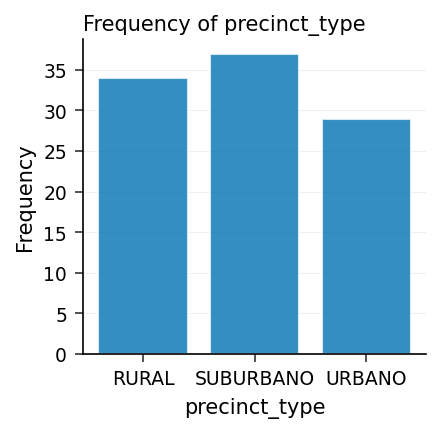

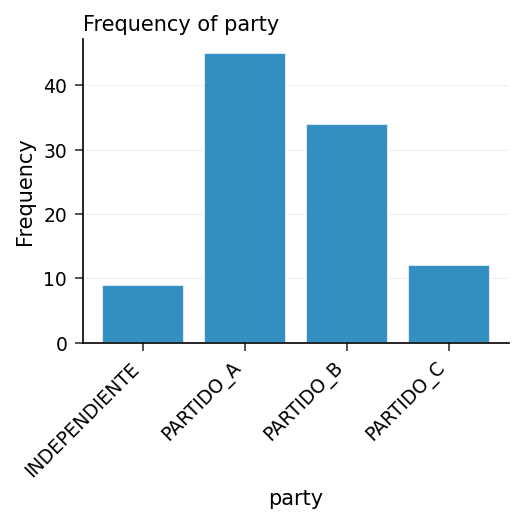

In [2]:
/* --------------------------------------------------------
   Distribucion base de tipo de precinto y partido
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.precinct_votes;
    TABLES precinct_type / nocum;
    TABLES party / nocum;
    ETIQUETA precinct_type="Tipo de Precinto" party="Partido";
EJECUTAR;


---


NOTE: PROC SGPLOT data=work.precinct_votes

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


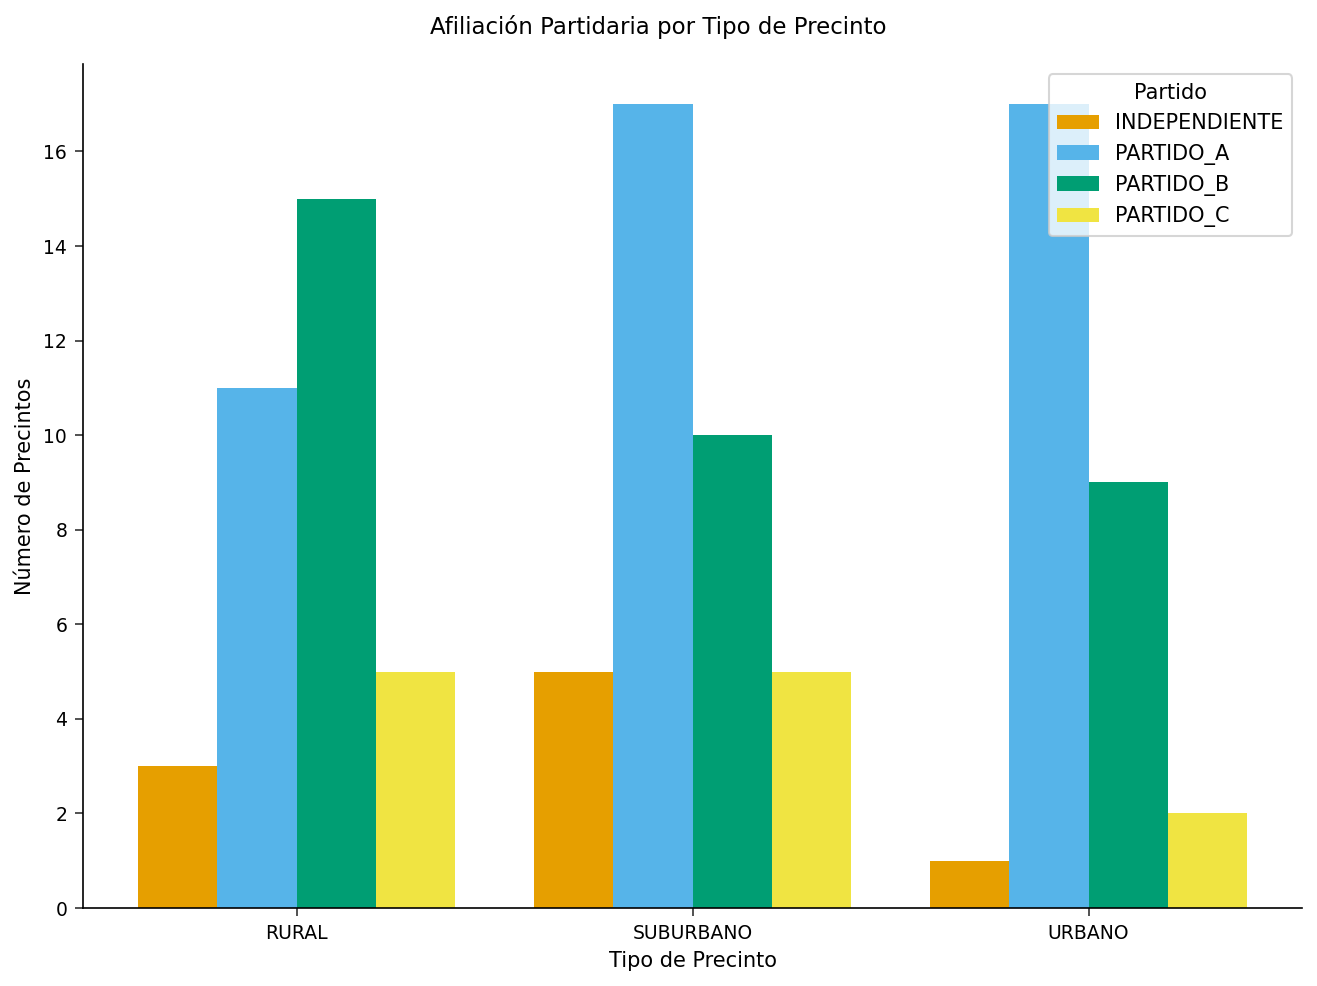

In [3]:
/* --------------------------------------------------------
   Afiliacion partidaria por tipo de precinto (conteo de precintos)
   -------------------------------------------------------- */
PROCEDIMIENTO SGPLOT DATOS=work.precinct_votes;
    VBAR precinct_type / GROUP=party GROUPDISPLAY=CLUSTER
        STAT=FRECUENCIAS;
    XAXIS ETIQUETA='Tipo de Precinto';
    YAXIS ETIQUETA='Número de Precintos';
    keylegend / TÍTULO='Partido';
    TÍTULO 'Afiliación Partidaria por Tipo de Precinto';
EJECUTAR;


---

                         Tipo de Precinto por Partido: Tabulación Cruzada con Conteos Esperados                         

                                                   The FREQ Procedure

Table of Tipo de Precinto by Partido

Tipo de Precinto |INDEPENDIENTE |    PARTIDO_A |    PARTIDO_B |    PARTIDO_C |         Total
-----------------+--------------+--------------+--------------+--------------+--------------
RURAL            |            3 |           11 |           15 |            5 |            34
                 |         3.00 |        11.00 |        15.00 |         5.00 |         34.00
                 |         3.06 |        15.30 |        11.56 |         4.08 |              
                 |         8.82 |        32.35 |        44.12 |        14.71 |        100.00
                 |        33.33 |        24.44 |        44.12 |        41.67 |         34.00
-----------------+--------------+--------------+--------------+--------------+--------------
SUBURBANO        |       


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.


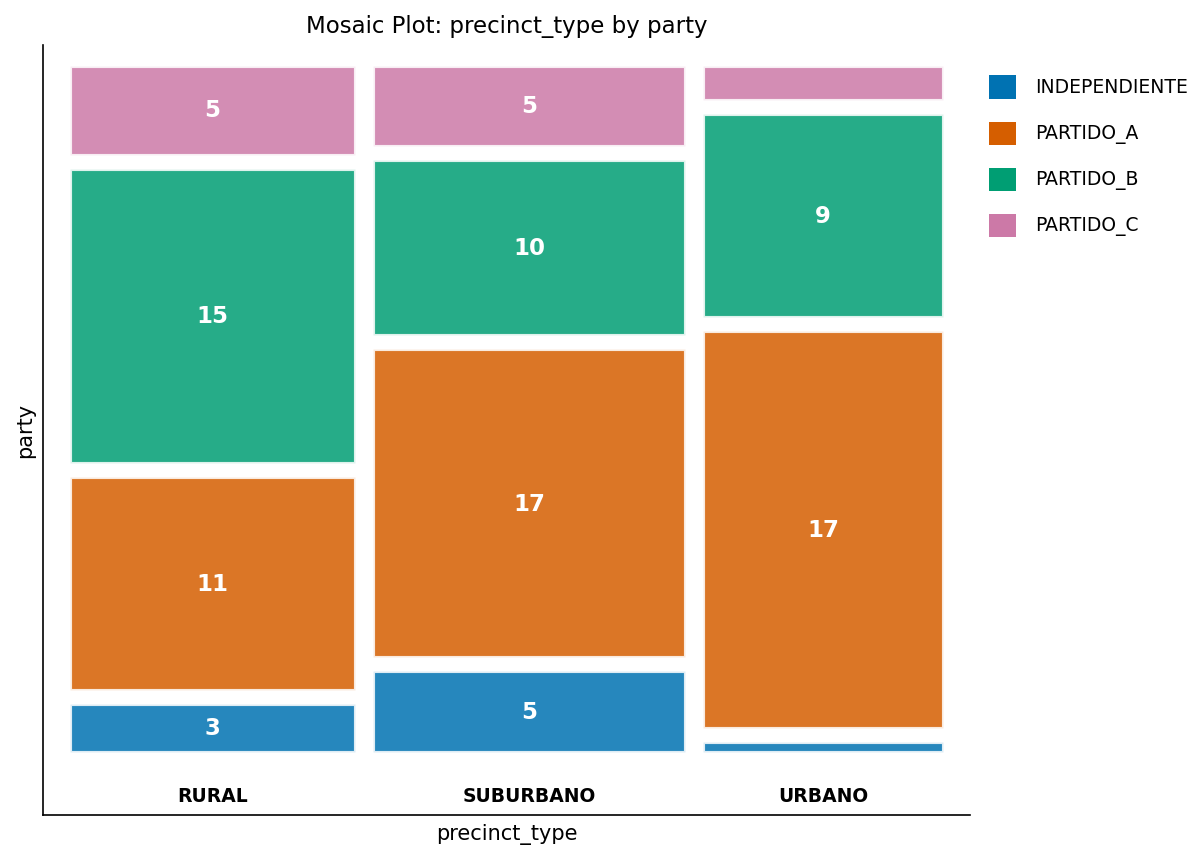

In [4]:
/* --------------------------------------------------------
   Tabulacion cruzada de tipo de precinto x partido.
   Solicitar conteos ESPERADOS para que las celdas dispersas
   sean visibles, mas la prueba asintotica de chi-cuadrado de
   Pearson de asociacion general. Observe los conteos
   esperados pequenos en las columnas INDEPENDIENTE y
   PARTIDO_C -- la senal de que una prueba de tendencia
   ordenada y exacta es la mejor herramienta inferencial.
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.precinct_votes;
    TABLES precinct_type * party / chisq expected;
    ETIQUETA precinct_type="Tipo de Precinto" party="Partido";
    TÍTULO 'Tipo de Precinto por Partido: Tabulación Cruzada con Conteos Esperados';
EJECUTAR;


           Prueba de Tendencia de Cochran-Armitage: Apoyo al Partido A a lo Largo del Gradiente de Precintos            

                                                   The FREQ Procedure

Table of Orden del Tipo de Precinto by Indicador Partido A

Orden del Tipo de Precinto |         0 |         1 |      Total
---------------------------+-----------+-----------+-----------
1                          |        12 |        17 |         29
                           |     12.00 |     17.00 |      29.00
                           |     41.38 |     58.62 |     100.00
                           |     21.82 |     37.78 |      29.00
---------------------------+-----------+-----------+-----------
2                          |        20 |        17 |         37
                           |     20.00 |     17.00 |      37.00
                           |     54.05 |     45.95 |     100.00
                           |     36.36 |     37.78 |      37.00
---------------------------+-----------+---


NOTE: DATA work.precinct_ordinal


NOTE: Read 100 rows from work.precinct_votes.
NOTE: Wrote work.precinct_ordinal (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_type_order_party_a_flag.spec.json
NOTE: PROC FREQ statement used.


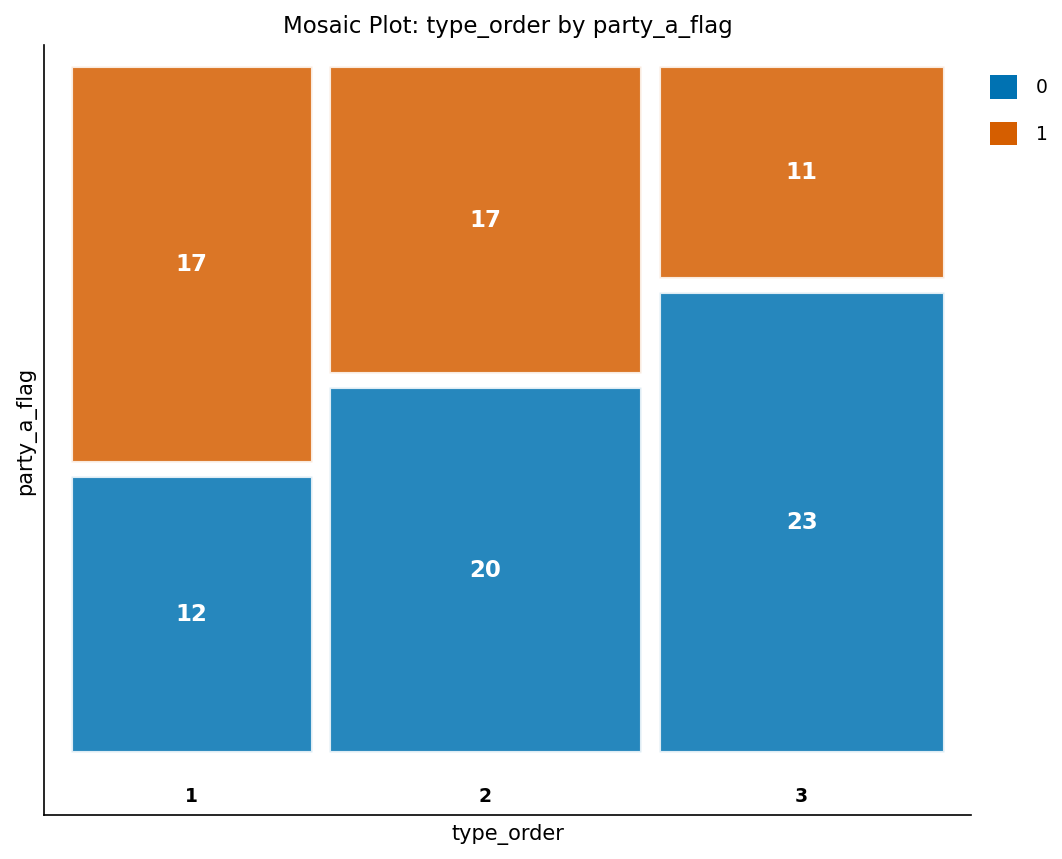

In [5]:
/* --------------------------------------------------------
   Prueba de tendencia de Cochran-Armitage. Recodificar el
   tipo de precinto a un puntaje ordinal (1=Urbano,
   2=Suburbano, 3=Rural) y probar si el apoyo al Partido A
   muestra una tendencia monotonica a lo largo del
   gradiente. EXACT TREND solicita el valor p exacto,
   apropiado dado los conteos de celda pequenos.
   -------------------------------------------------------- */
DATOS work.precinct_ordinal;
    ESTABLECER work.precinct_votes;
    /* Codificacion ordinal: 1=Urbano, 2=Suburbano, 3=Rural */
    SI precinct_type = 'URBANO' ENTONCES type_order = 1;
    SINO SI precinct_type = 'SUBURBANO' ENTONCES type_order = 2;
    SINO type_order = 3;
    /* Resultado binario: Partido A vs. todas las demas afiliaciones */
    party_a_flag = (party = 'PARTIDO_A');
    ETIQUETA type_order="Orden del Tipo de Precinto" party_a_flag="Indicador Partido A";
EJECUTAR;

PROCEDIMIENTO FRECUENCIAS DATOS=work.precinct_ordinal;
    TABLES type_order * party_a_flag / chisq trend;
    EXACT trend;
    ETIQUETA type_order="Orden del Tipo de Precinto" party_a_flag="Indicador Partido A";
    TÍTULO 'Prueba de Tendencia de Cochran-Armitage: Apoyo al Partido A a lo Largo del Gradiente de Precintos';
EJECUTAR;


                                  Distribución del Tipo de Precinto Dentro del Condado                                  

                                                   The FREQ Procedure

Table of Condado by Tipo de Precinto

Condado   |     RURAL | SUBURBANO |    URBANO |      Total
----------+-----------+-----------+-----------+-----------
ADAMS     |         5 |        10 |         4 |         19
          |      5.00 |     10.00 |      4.00 |      19.00
          |     26.32 |     52.63 |     21.05 |     100.00
          |     14.71 |     27.03 |     13.79 |      19.00
----------+-----------+-----------+-----------+-----------
HAMILTON  |         7 |         7 |         7 |         21
          |      7.00 |      7.00 |      7.00 |      21.00
          |     33.33 |     33.33 |     33.33 |     100.00
          |     20.59 |     18.92 |     24.14 |      21.00
----------+-----------+-----------+-----------+-----------
JEFFERSON |         4 |         7 |         7 |         18
  


NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_county_name_precinct_type.spec.json
NOTE: PROC FREQ statement used.


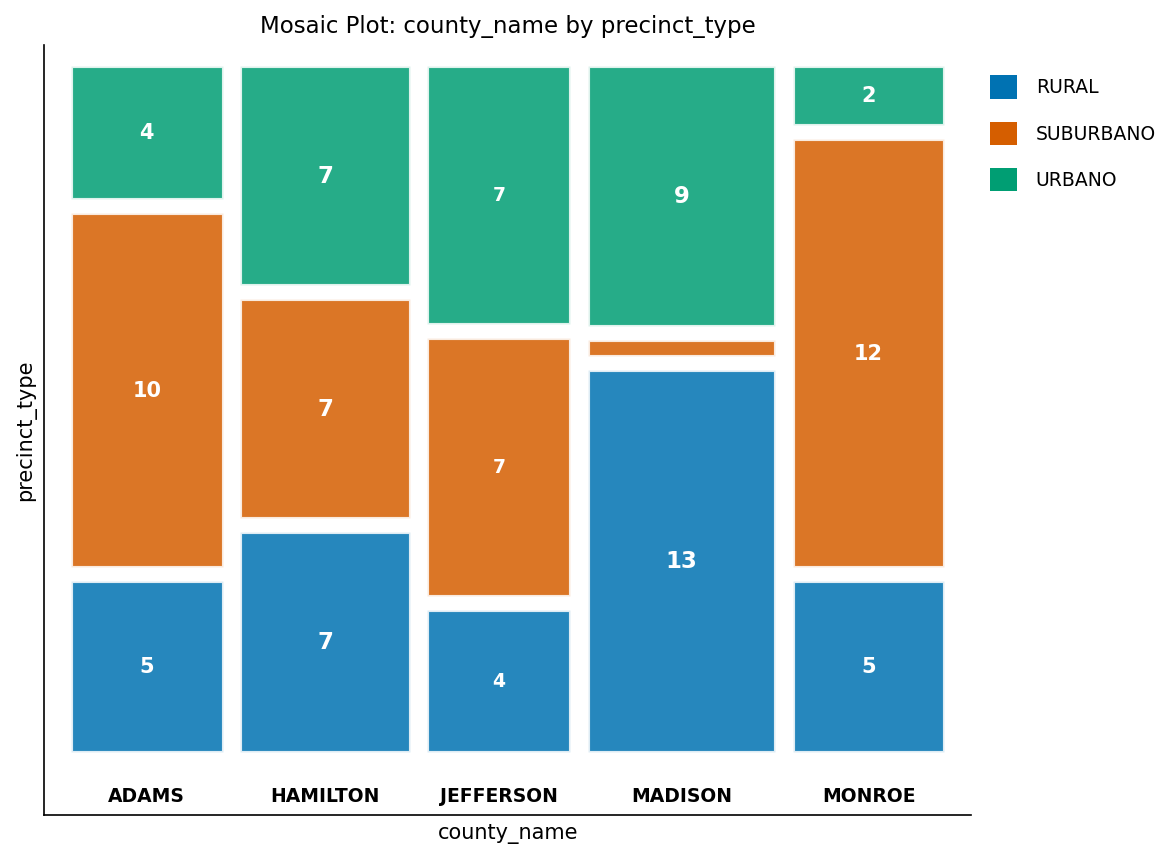

In [6]:
/* --------------------------------------------------------
   Vista a nivel de condado: como varia la mezcla
   urbano/suburbano/rural entre los cinco condados. Esto
   contextualiza el resultado de la tendencia -- el
   gradiente de precintos esta presente en cada condado,
   pero su composicion difiere.
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.precinct_votes;
    TABLES county_name * precinct_type / nocum;
    ETIQUETA county_name="Condado" precinct_type="Tipo de Precinto";
    TÍTULO 'Distribución del Tipo de Precinto Dentro del Condado';
EJECUTAR;


---

### Interpretación

A través de los 100 precintos, el Partido A tiene una pluralidad general
(45 precintos), seguido por el Partido B (34), el Partido C (12), y los
Independientes (9). La tabulación cruzada muestra que la participación
del Partido A sigue un claro gradiente de urbano a rural: representa el
58.6% de los precintos urbanos, 46.0% de los precintos suburbanos, y
32.4% de los precintos rurales, mientras que el Partido B se mueve en la
dirección opuesta, aumentando de 31.0% urbano a 44.1% rural.

La prueba ómnibus de chi-cuadrado de Pearson de asociación general **no**
es estadísticamente significativa (chi-cuadrado = 6.78, 6 gl, p = 0.3418;
V de Cramer = 0.18). Ese resultado también es frágil: la presentación de
conteos esperados revela varias celdas por debajo de cinco — por ejemplo,
la columna Independiente tiene conteos esperados de 3.06, 3.33, y 2.61, y
los independientes urbanos suman solo un precinto — por lo que la
aproximación de chi-cuadrado de muestra grande no es confiable aquí.

La prueba de tendencia de Cochran-Armitage precisa la pregunta usando la
puntuación ordinal urbano-suburbano-rural. Detecta la disminución
monotónica en el apoyo al Partido A que la prueba ómnibus pasa por alto:
chi-cuadrado de tendencia = 4.38 con un Pr > ChiSq asintótico = 0.0363 y
un **Pr >= |Z| exacto = 0.0431**, significativo al nivel de 0.05. Este es
el resultado analítico clave — una prueba focalizada, exacta, de un solo
grado de libertad recupera una señal direccional real que la prueba de
asociación genérica de 6 grados de libertad, debilitada por celdas
dispersas, no detecta.

La vista a nivel de condado confirma que la división urbano/suburbano/
rural está presente en los cinco condados, aunque la mezcla difiere:
Madison es el más rural (13 de 23 precintos rurales) mientras que Monroe
es el más suburbano (12 de 19). Para la evaluación de impacto de
redistribución, la conclusión es que los cambios de límites que desplacen
precintos a lo largo del eje urbano-rural alterarían de forma medible la
composición partidaria, y que esta tendencia geográfica está mejor
evidenciada por la prueba de tendencia exacta que por el chi-cuadrado
ómnibus.


---

                                  Distribución del Tipo de Precinto Dentro del Condado                                  

                                                   The FREQ Procedure

Table of Tipo de Precinto by Partido

Tipo de Precinto |INDEPENDIENTE |    PARTIDO_A |    PARTIDO_B |    PARTIDO_C |         Total
-----------------+--------------+--------------+--------------+--------------+--------------
RURAL            |            3 |           11 |           15 |            5 |            34
                 |         3.00 |        11.00 |        15.00 |         5.00 |         34.00
                 |         8.82 |        32.35 |        44.12 |        14.71 |        100.00
                 |        33.33 |        24.44 |        44.12 |        41.67 |         34.00
-----------------+--------------+--------------+--------------+--------------+--------------
SUBURBANO        |            5 |           17 |           10 |            5 |            37
                 |       


NOTE: PROC FREQ
NOTE: Output dataset work.voting_pattern_summary has 12 observations and 4 variables.
NOTE: ODS plot written: freq_mosaic_precinct_type_party.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC EXPORT data=work.voting_pattern_summary outfile=precinct_voting_patterns.csv

NOTE: Exported 12 rows to precinct_voting_patterns.csv.


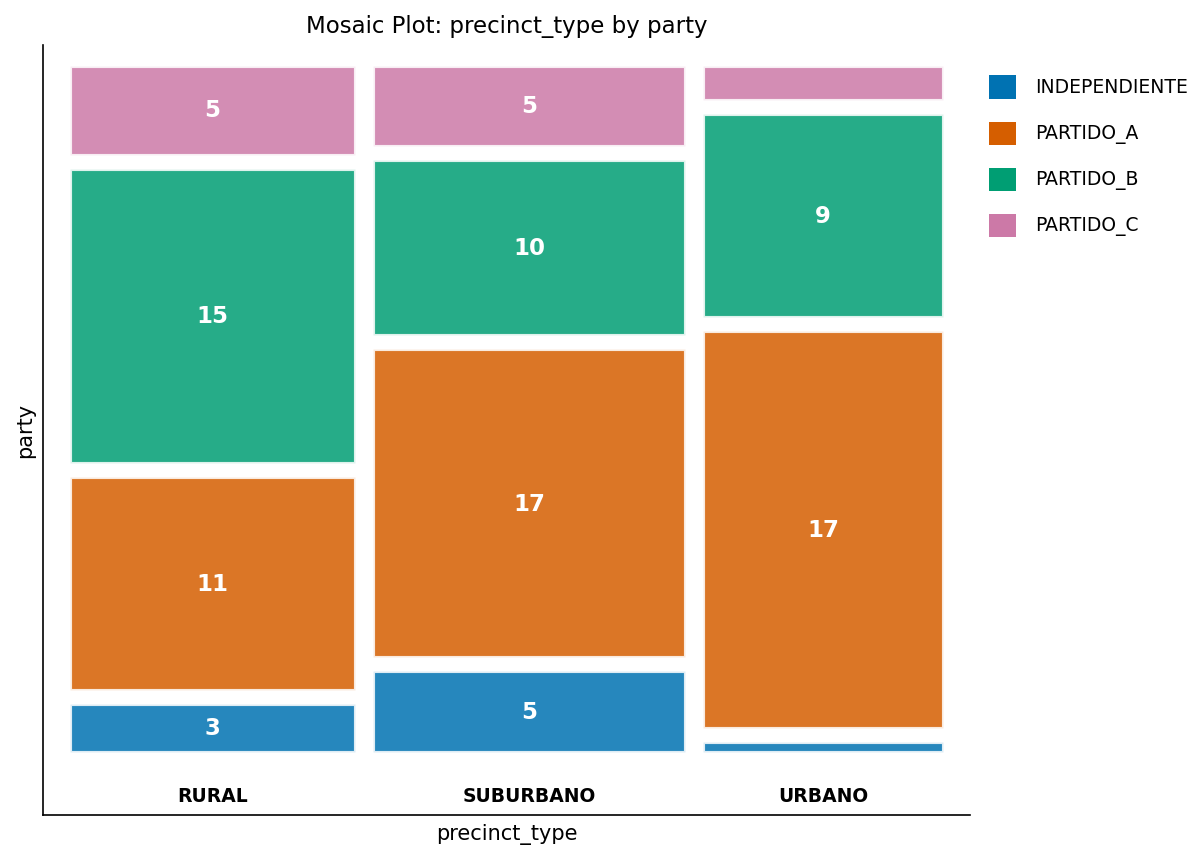

In [7]:
/* --------------------------------------------------------
   Exportar el resumen de tipo de precinto x partido para
   la evaluacion de impacto de redistribucion posterior.
   -------------------------------------------------------- */
PROCEDIMIENTO FRECUENCIAS DATOS=work.precinct_votes;
    TABLES precinct_type * party / out=work.voting_pattern_summary nocum;
EJECUTAR;

PROCEDIMIENTO EXPORT DATOS=work.voting_pattern_summary
    OUTFILE='precinct_voting_patterns.csv'
    DBMS=csv REPLACE;
EJECUTAR;


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Confidencial
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Powered by <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>